In [1]:
!pip -q install gdown
import os
import gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, roc_curve, roc_auc_score)
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
# downloads csv files directly onto Google Colab without having to set up Google Drive path
data_dir = '/content/data'
os.makedirs(data_dir, exist_ok=True)

files = {
    'neighbourhoods.csv' : '1fjAyFEJGWg2gILzndlGLZItvr7idhD2C',
    'neighbourhoods.geojson' :'1LSvATSRNNqDwBlLdbTCKbanA7EQRVeCg',
    'listings.csv.gz': '1nkq7LNOumg8y63pBN8mp-m0Sx9vGXLjA',
     'calendar.csv.gz' : '1J7SaQYlLALyYpFCq8QHSMl0mXy46dS59',
    'reviews.csv.gz' : '1fWyrWnGqq-9U0wp76kuab14YjYwNjjgv',
    'listings.csv': '1KPla33OHNLOm-7BBcjVZ-Cah9FAlDIRh',
    'reviews.csv' : '1LU63PXcF3VFrZZi7IBdgecTyJCJUwhQH'
}

for filename, file_id in files.items():
    out_path = os.path.join(data_dir, filename)
    if not os.path.exists(out_path):
        gdown.download(
            f'https://drive.google.com/uc?id={file_id}',
            out_path,
            quiet=False
        )

Downloading...
From: https://drive.google.com/uc?id=1fjAyFEJGWg2gILzndlGLZItvr7idhD2C
To: /content/data/neighbourhoods.csv
100%|██████████| 240/240 [00:00<00:00, 708kB/s]
Downloading...
From: https://drive.google.com/uc?id=1LSvATSRNNqDwBlLdbTCKbanA7EQRVeCg
To: /content/data/neighbourhoods.geojson
100%|██████████| 84.8k/84.8k [00:00<00:00, 40.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1nkq7LNOumg8y63pBN8mp-m0Sx9vGXLjA
To: /content/data/listings.csv.gz
100%|██████████| 196k/196k [00:00<00:00, 63.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1J7SaQYlLALyYpFCq8QHSMl0mXy46dS59
To: /content/data/calendar.csv.gz
100%|██████████| 396k/396k [00:00<00:00, 59.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fWyrWnGqq-9U0wp76kuab14YjYwNjjgv
To: /content/data/reviews.csv.gz
100%|██████████| 2.59M/2.59M [00:00<00:00, 172MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KPla33OHNLOm-7BBcjVZ-Cah9FAlDIRh
To: /content/data/listings.csv
100%|██████████| 80

In [3]:
listings = pd.read_csv('/content/data/listings.csv')
listingsgz = pd.read_csv('/content/data/listings.csv.gz')
reviews = pd.read_csv('/content/data/reviews.csv')
calendargz = pd.read_csv('/content/data/calendar.csv.gz')
neighbourhoods = pd.read_csv('/content/data/neighbourhoods.csv')
neighbourhoods_geojson = pd.read_json('/content/data/neighbourhoods.geojson')
reviewsgz = pd.read_csv('/content/data/reviews.csv.gz')
calendargz = pd.read_csv('/content/data/calendar.csv.gz')


# Initial EDA

1. Loading & Cleaning Data

In [4]:
df = pd.read_csv('/content/data/listings.csv.gz')

# Amenity count
df['amenity_count'] = (df['amenities']
                         .str.count(r'\"[^\"]+\"')
                         .where(df['amenities'].notna()))

# Boolean encodings
df['is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0})
df['is_verified']  = df['host_identity_verified'].map({'t': 1, 'f': 0})
df['instant_book'] = df['instant_bookable'].map({'t': 1, 'f': 0})

# Host tenure
df['host_tenure_yrs'] = df['hosts_time_as_host_years']

# Rated subset
rated = df.dropna(subset=['review_scores_rating']).copy()

print(f"Total listings : {len(df)}")
print(f"Rated listings : {len(rated)}  ({len(rated)/len(df)*100:.1f}%)")
print("\nMissing values in key columns:")
key_cols = ['review_scores_rating', 'review_scores_cleanliness',
            'review_scores_value', 'review_scores_location',
            'amenity_count', 'is_superhost', 'host_tenure_yrs',
            'estimated_occupancy_l365d', 'number_of_reviews']
print(df[key_cols].isnull().sum())

Total listings : 453
Rated listings : 395  (87.2%)

Missing values in key columns:
review_scores_rating         58
review_scores_cleanliness    58
review_scores_value          58
review_scores_location       58
amenity_count                 0
is_superhost                  0
host_tenure_yrs               0
estimated_occupancy_l365d     0
number_of_reviews             0
dtype: int64


2. Overall Rating Distribution

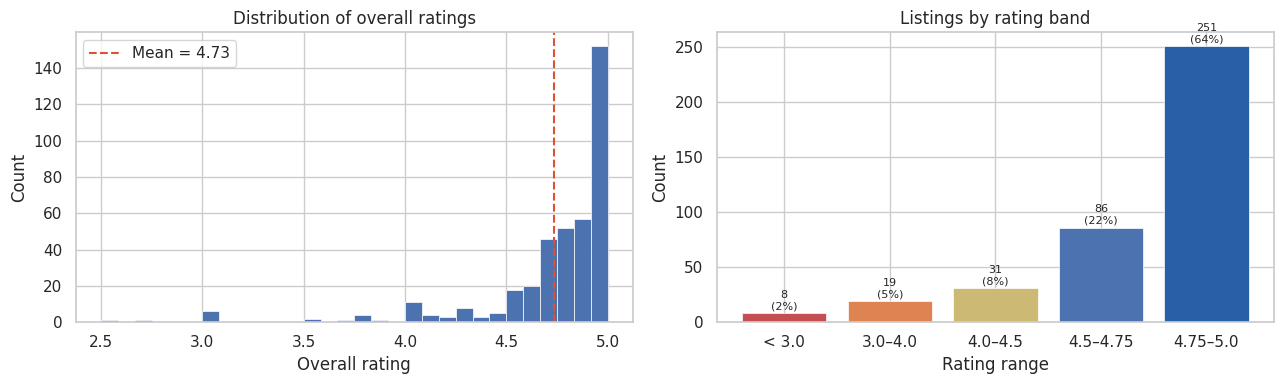

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(rated['review_scores_rating'], bins=30,
             color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].axvline(rated['review_scores_rating'].mean(), color='#DD5033',
                linestyle='--', linewidth=1.5,
                label=f"Mean = {rated['review_scores_rating'].mean():.2f}")
axes[0].set_title('Distribution of overall ratings')
axes[0].set_xlabel('Overall rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# Rating band breakdown
bands = pd.cut(rated['review_scores_rating'],
               bins=[0, 3, 4, 4.5, 4.75, 5.001],
               labels=['< 3.0', '3.0–4.0', '4.0–4.5', '4.5–4.75', '4.75–5.0'])
band_counts = bands.value_counts().sort_index()
colors = ['#c44e52', '#dd8452', '#ccb974', '#4c72b0', '#295fa6']
axes[1].bar(band_counts.index.astype(str), band_counts.values,
            color=colors, edgecolor='white', linewidth=0.5)
for i, (val, cnt) in enumerate(zip(band_counts.index, band_counts.values)):
    axes[1].text(i, cnt + 1.5, f'{cnt}\n({cnt/len(rated)*100:.0f}%)',
                 ha='center', va='bottom', fontsize=8)
axes[1].set_title('Listings by rating band')
axes[1].set_xlabel('Rating range')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

3. Sub-Ratings (means + standard deviation)

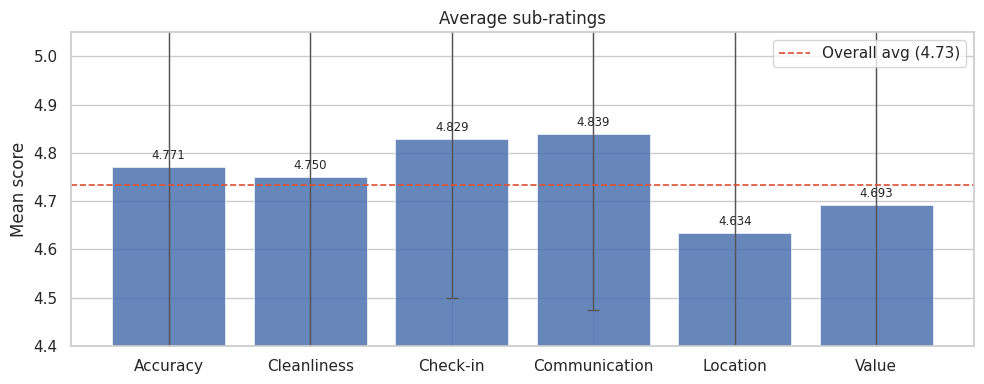

In [6]:
sub_cols = {
    'review_scores_accuracy':      'Accuracy',
    'review_scores_cleanliness':   'Cleanliness',
    'review_scores_checkin':       'Check-in',
    'review_scores_communication': 'Communication',
    'review_scores_location':      'Location',
    'review_scores_value':         'Value',
}

sub_means = rated[list(sub_cols)].mean().rename(sub_cols)
sub_stds  = rated[list(sub_cols)].std().rename(sub_cols)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(sub_means))
bars = ax.bar(x, sub_means.values, yerr=sub_stds.values, capsize=4,
              color='#4C72B0', alpha=0.85, edgecolor='white', linewidth=0.5,
              error_kw=dict(elinewidth=1, ecolor='#555'))

for bar, val in zip(bars, sub_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='500')

ax.set_xticks(x)
ax.set_xticklabels(sub_means.index)
ax.set_ylim(4.4, 5.05)
ax.set_title('Average sub-ratings')
ax.set_ylabel('Mean score')
ax.axhline(rated['review_scores_rating'].mean(), color='#DD5033',
           linestyle='--', linewidth=1.2,
           label=f'Overall avg ({rated["review_scores_rating"].mean():.2f})')
ax.legend()
plt.tight_layout()
plt.show()

4. Correlation Heatmap

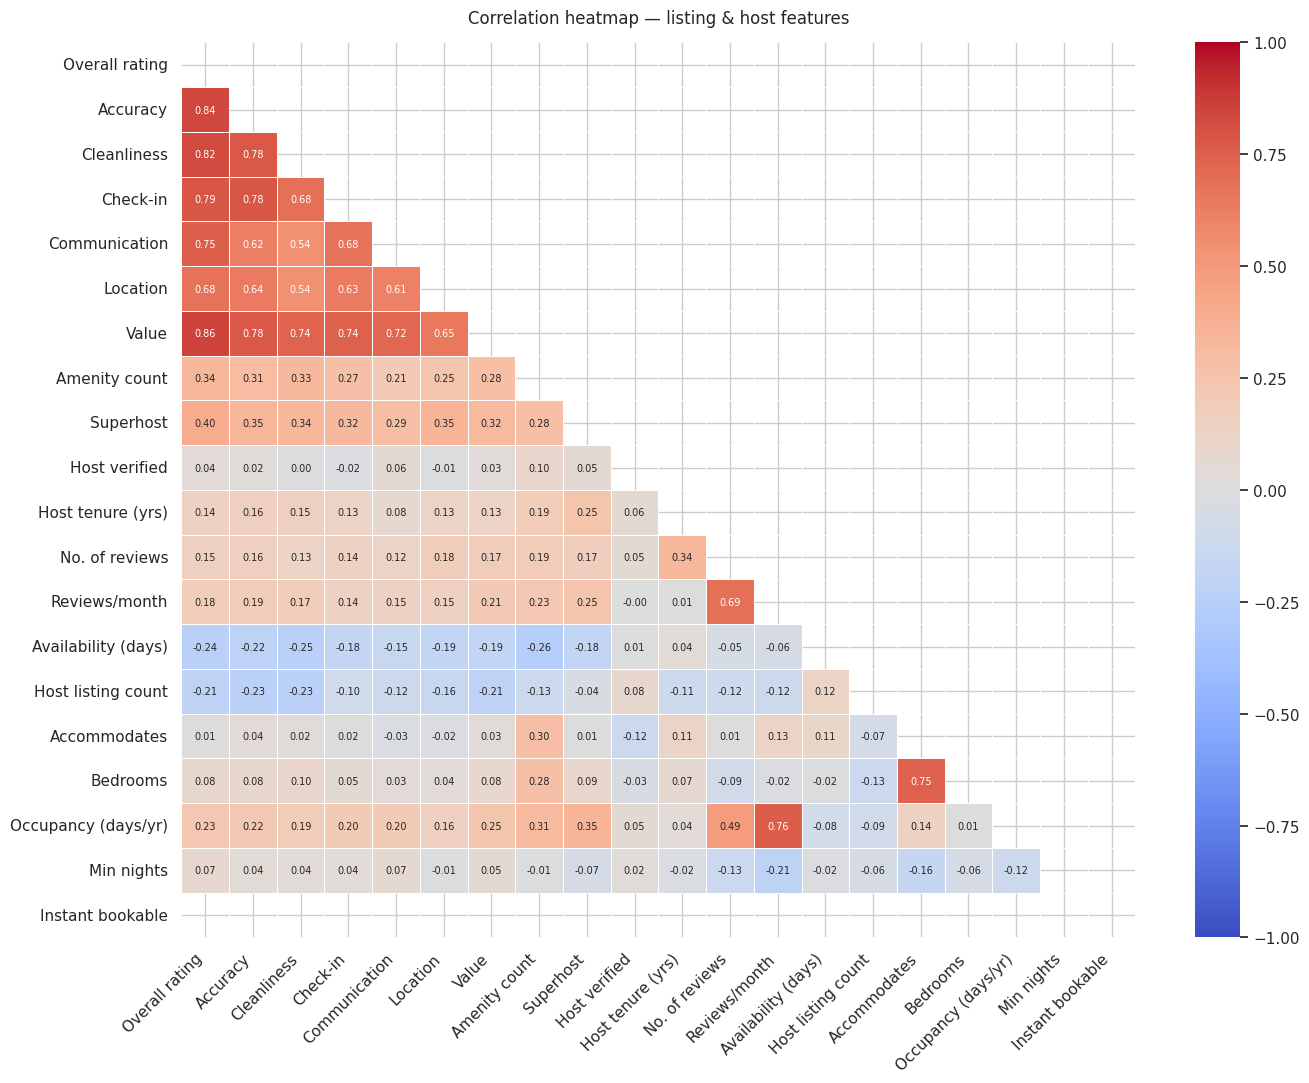

In [7]:
corr_cols = {
    'review_scores_rating':           'Overall rating',
    'review_scores_accuracy':         'Accuracy',
    'review_scores_cleanliness':      'Cleanliness',
    'review_scores_checkin':          'Check-in',
    'review_scores_communication':    'Communication',
    'review_scores_location':         'Location',
    'review_scores_value':            'Value',
    'amenity_count':                  'Amenity count',
    'is_superhost':                   'Superhost',
    'is_verified':                    'Host verified',
    'host_tenure_yrs':                'Host tenure (yrs)',
    'number_of_reviews':              'No. of reviews',
    'reviews_per_month':              'Reviews/month',
    'availability_365':               'Availability (days)',
    'calculated_host_listings_count': 'Host listing count',
    'accommodates':                   'Accommodates',
    'bedrooms':                       'Bedrooms',
    'estimated_occupancy_l365d':      'Occupancy (days/yr)',
    'minimum_nights':                 'Min nights',
    'instant_book':                   'Instant bookable',
}

corr_df     = rated[list(corr_cols)].rename(columns=corr_cols)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation heatmap — listing & host features', pad=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### RQ1 - What listing and host characteristics are most associated with higher ratings?

/tmp/ipykernel_1663/2096328821.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_1663/2096328821.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_1663/2096328821.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


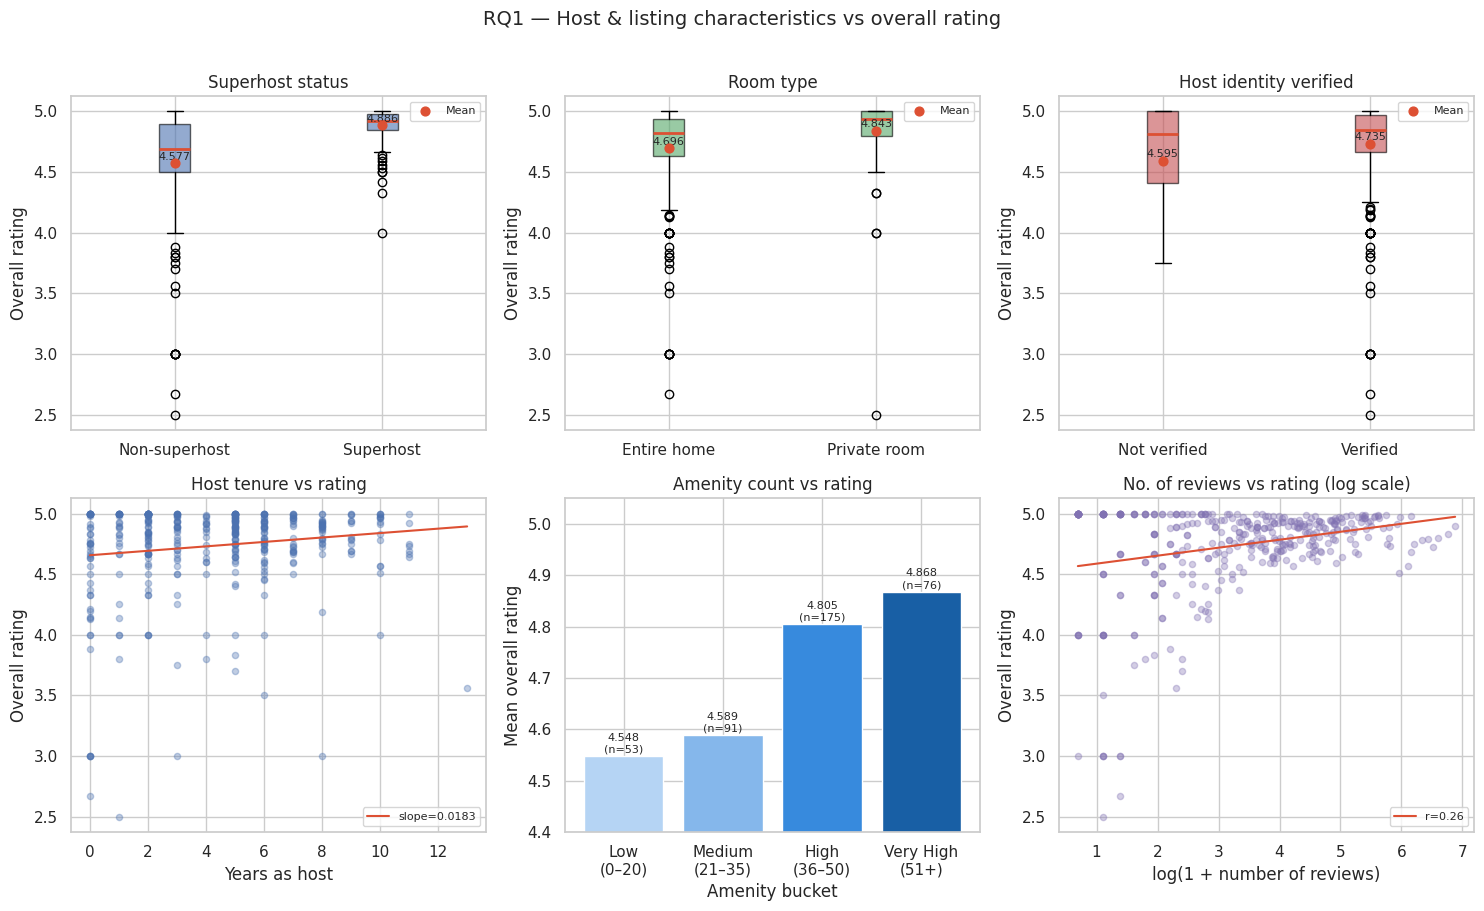

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('RQ1 — Host & listing characteristics vs overall rating', fontsize=14, y=1.01)

rating_col = 'review_scores_rating'


def boxplot_with_mean(ax, data, labels, title, color='#4C72B0'):
    ax.boxplot(
        data,
        labels=labels,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='#DD5033', linewidth=2)
    )

    means = [d.mean() for d in data]
    ax.scatter(range(1, len(means) + 1), means, color='#DD5033', zorder=5, s=40, label='Mean')

    for i, mean in enumerate(means, start=1):
        ax.text(i, mean + 0.01, f'{mean:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(title)
    ax.set_ylabel('Overall rating')
    ax.legend(fontsize=8)


def scatter_with_trend(ax, x, y, title, xlabel, color='#4C72B0', label_type='slope'):
    valid = pd.DataFrame({'x': x, 'y': y}).dropna()

    ax.scatter(valid['x'], valid['y'], alpha=0.35, s=20, color=color)

    m, b = np.polyfit(valid['x'], valid['y'], 1)
    x_line = np.linspace(valid['x'].min(), valid['x'].max(), 100)

    if label_type == 'corr':
        label = f'r={valid["x"].corr(valid["y"]):.2f}'
    else:
        label = f'slope={m:.4f}'

    ax.plot(x_line, m * x_line + b, color='#DD5033', linewidth=1.5, label=label)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Overall rating')
    ax.legend(fontsize=8)


# Superhost status
boxplot_with_mean(
    axes[0, 0],
    [
        rated.loc[rated['host_is_superhost'] == 'f', rating_col],
        rated.loc[rated['host_is_superhost'] == 't', rating_col]
    ],
    ['Non-superhost', 'Superhost'],
    'Superhost status'
)

# Room type
boxplot_with_mean(
    axes[0, 1],
    [
        rated.loc[rated['room_type'] == 'Entire home/apt', rating_col],
        rated.loc[rated['room_type'] == 'Private room', rating_col]
    ],
    ['Entire home', 'Private room'],
    'Room type',
    color='#55A868'
)

# Host identity verified
boxplot_with_mean(
    axes[0, 2],
    [
        rated.loc[rated['host_identity_verified'] == 'f', rating_col],
        rated.loc[rated['host_identity_verified'] == 't', rating_col]
    ],
    ['Not verified', 'Verified'],
    'Host identity verified',
    color='#C44E52'
)

# Host tenure vs rating
scatter_with_trend(
    axes[1, 0],
    rated['host_tenure_yrs'],
    rated[rating_col],
    'Host tenure vs rating',
    'Years as host'
)

# Amenity count buckets
rated = rated.copy()

rated['amenity_bucket'] = pd.cut(
    rated['amenity_count'],
    bins=[0, 20, 35, 50, 90],
    labels=['Low\n(0–20)', 'Medium\n(21–35)', 'High\n(36–50)', 'Very High\n(51+)']
)

amenity_summary = (
    rated
    .groupby('amenity_bucket', observed=True)[rating_col]
    .agg(['mean', 'count'])
)

bars = axes[1, 1].bar(
    amenity_summary.index.astype(str),
    amenity_summary['mean'],
    color=['#B5D4F4', '#85B7EB', '#378ADD', '#185FA5'],
    edgecolor='white'
)

for bar, mean, count in zip(bars, amenity_summary['mean'], amenity_summary['count']):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{mean:.3f}\n(n={count})',
        ha='center',
        va='bottom',
        fontsize=8
    )

axes[1, 1].set_ylim(4.4, 5.05)
axes[1, 1].set_title('Amenity count vs rating')
axes[1, 1].set_xlabel('Amenity bucket')
axes[1, 1].set_ylabel('Mean overall rating')

# Number of reviews vs rating
scatter_with_trend(
    axes[1, 2],
    np.log1p(rated['number_of_reviews']),
    rated[rating_col],
    'No. of reviews vs rating (log scale)',
    'log(1 + number of reviews)',
    color='#8172B2',
    label_type='corr'
)

plt.tight_layout()
plt.show()

Listings with more amenities show the strongest relationship with higher ratings, increasing steadily from about 4.55 for low-amenity listings to nearly 4.87 for very high-amenity listings, suggesting that added features significantly improve guest experience. Superhost status is also a key factor, with superhosts averaging around 4.9 compared to about 4.57 for non-superhosts, and showing more consistent high ratings. Similarly, verified hosts tend to receive higher ratings (~4.74 vs ~4.60), indicating that trust and credibility play an important role in guest satisfaction. The number of reviews has a moderate positive relationship with ratings (r ≈ 0.26), implying that listings with more reviews tend to maintain stronger reputations over time. Room type shows only a small difference, with private rooms slightly outperforming entire homes, while host tenure has a very weak positive effect, indicating that experience contributes minimally compared to other factors. Overall, amenities, superhost status, and verification emerge as the most influential characteristics associated with higher ratings.

### RQ2 - Do listings that indicate they would be more expensive get rated higher (room type, room size, amenities)- or do guests have higher expectations and rate more critically?


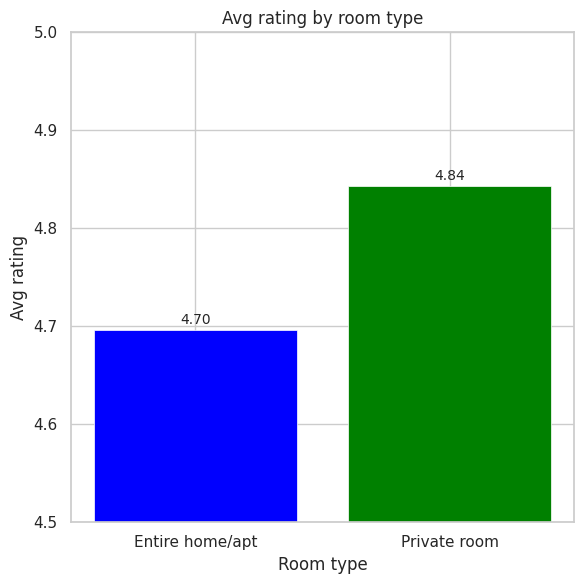

In [9]:
fig, ax= plt.subplots(figsize=(6, 6))

rt_means = rated.groupby('room_type')['review_scores_rating'].mean()
colors = ['blue', 'green']
ax.bar(rt_means.index, rt_means.values, color=colors, linewidth=0.5)
ax.set_ylim(4.5, 5.0)
for i, (rt, val) in enumerate(rt_means.items()):
    ax.text(i, val + 0.003, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
ax.set_title('Avg rating by room type')
ax.set_xlabel('Room type')
ax.set_ylabel('Avg rating')

plt.tight_layout()
plt.show()

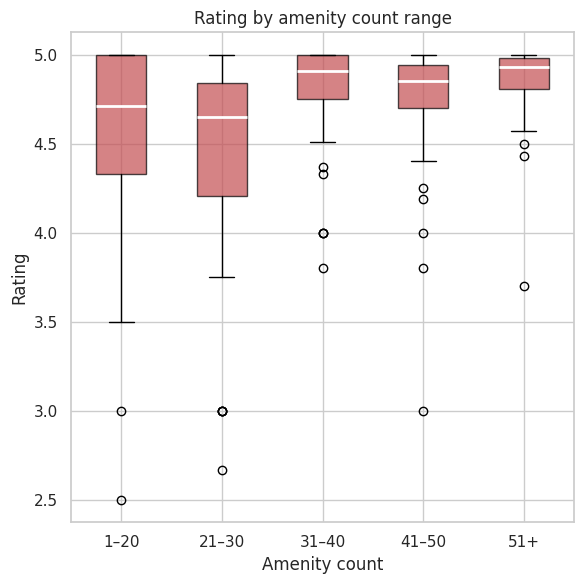

In [10]:
amenity_rated = rated.dropna(subset=['amenity_count'])

fig, ax= plt.subplots(figsize=(6, 6))

amenity_rated = amenity_rated.copy()
amenity_rated['amenity_bin'] = pd.cut(
    amenity_rated['amenity_count'],
    bins=[0, 20, 30, 40, 50, 90],
    labels=['1–20', '21–30', '31–40', '41–50', '51+']
)
bin_labels = ['1–20', '21–30', '31–40', '41–50', '51+']
bin_data = [amenity_rated[amenity_rated['amenity_bin'] == b]['review_scores_rating'].dropna().values
            for b in bin_labels]
bp = ax.boxplot(bin_data, patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#C44E52')
    patch.set_alpha(0.7)
ax.set_xticklabels(bin_labels)
ax.set_title('Rating by amenity count range')
ax.set_xlabel('Amenity count')
ax.set_ylabel('Rating')

plt.tight_layout()
plt.show()

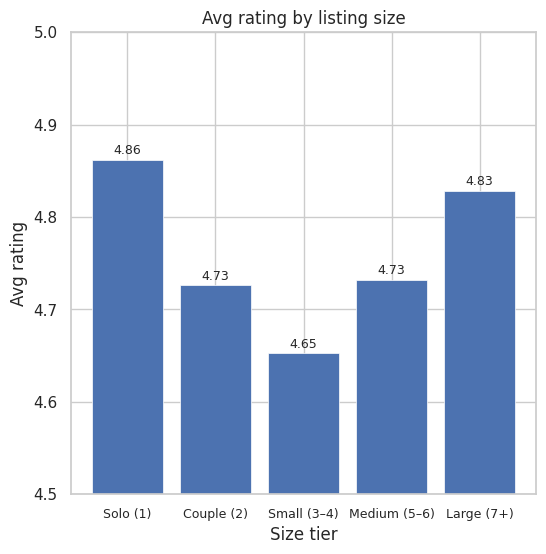

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))

bins   = [0, 1, 2, 4, 6, 16]
labels = ['Solo (1)', 'Couple (2)', 'Small (3–4)', 'Medium (5–6)', 'Large (7+)']
rated['size_tier'] = pd.cut(rated['accommodates'], bins=bins, labels=labels)

tier_means = rated.groupby('size_tier', observed=True)['review_scores_rating'].mean()
ax.bar(range(len(tier_means)), tier_means.values,
            color='#4C72B0', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(4.5, 5.0)
for i, val in enumerate(tier_means.values):
    ax.text(i, val + 0.003, f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Avg rating by listing size')
ax.set_xlabel('Size tier')
ax.set_ylabel('Avg rating')

plt.show()

### RQ3 - Which factors can a host actually change (cleanliness, response time) vs. which are fixed (location, neighborhood)?

In [12]:
# Controllable vs Fixed classification
controllable = [
    'amenity_count',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_accuracy',
    'review_scores_value',
]

fixed = [
    'review_scores_location',
    'host_tenure_yrs',
    'number_of_reviews',
    'accommodates',
    'bedrooms',
    'availability_365',
    'calculated_host_listings_count'
]

In [13]:
controllable_corr = {}
fixed_corr = {}

for col in controllable:
    if col in rated.columns:
        controllable_corr[col] = rated[col].corr(rated['review_scores_rating'])

for col in fixed:
    if col in rated.columns:
        fixed_corr[col] = rated[col].corr(rated['review_scores_rating'])

controllable_corr = pd.Series(controllable_corr).sort_values()
fixed_corr = pd.Series(fixed_corr).sort_values()

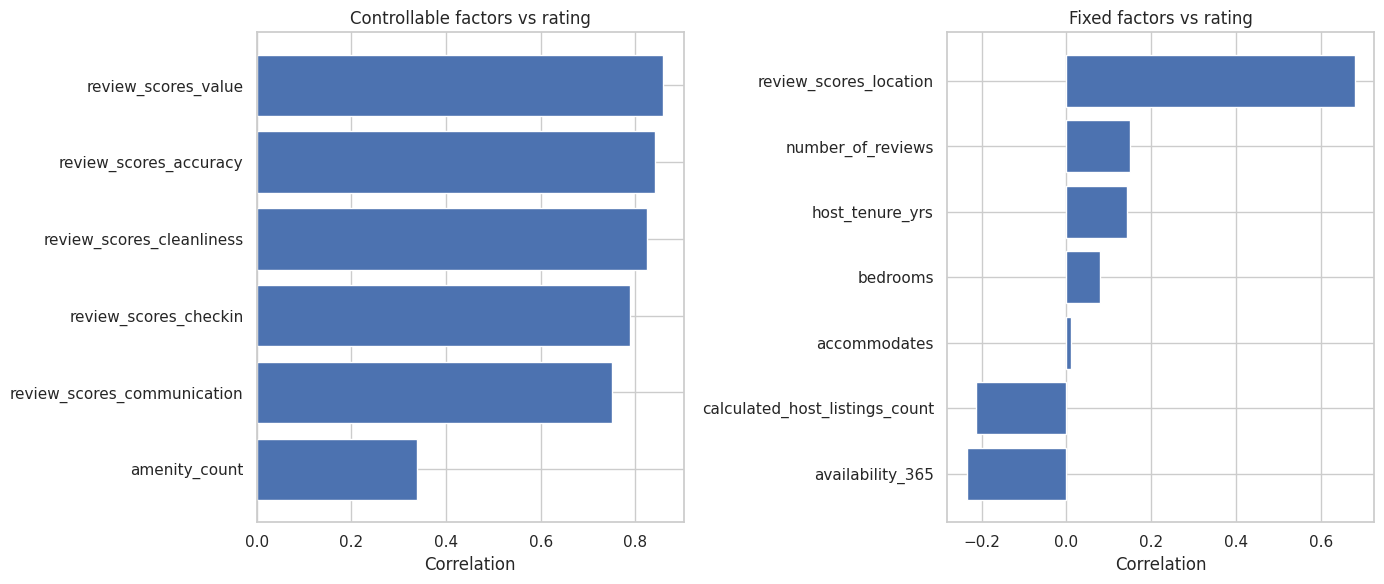

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#**Controllable**
axes[0].barh(controllable_corr.index, controllable_corr.values)
axes[0].set_title('Controllable factors vs rating')
axes[0].set_xlabel('Correlation')

# *Fixed*
axes[1].barh(fixed_corr.index, fixed_corr.values)
axes[1].set_title('Fixed factors vs rating')
axes[1].set_xlabel('Correlation')

plt.tight_layout()
plt.show()

When looking at the factors that influence overall ratings, there is a pretty defined separation between elements that hosts may actively change and those that are typically fixed. According to the correlational analysis and previous visualizations, several of the most powerful drivers of higher ratings fall into categories where hosts may actively improve. Things like cleanliness, communication, checking in experience, and listing accuracy all have a high positive correlation with total ratings. These include obviously actionable items, as hosts can improve cleaning methods, reply to guests promptly and clearly, streamline booking processes, and verify that listing descriptions truly reflect the property. Besides that, the number of amenities provided tends to have a positive impact, implying that hosts might increase guest satisfaction by including helpful or visually appealing items.

At the exact same time, several elements are either fixed or extremely difficult to modify. Geography is one of the most important characteristics, but it is completely out of the host's control once the property is officially established.  Neighborhood quality, home size, and structural aspects such as the number of bedrooms are difficult to change without significant effort. Though certain parameters, such as the amount of reviews or the host experience, may improve with time, they can not be modified right away and must be achieved through ongoing performance. The evaluation demonstrates that, while certain significant influencing variables, such as location, are fixed, many of the most significant determinants of higher ratings are within a host's control. Hosts can significantly boost their ratings by focusing on service quality, accuracy, and guest experience, even if they can't change the core characteristics of their property.

### Ranked Feature Correlations Summary

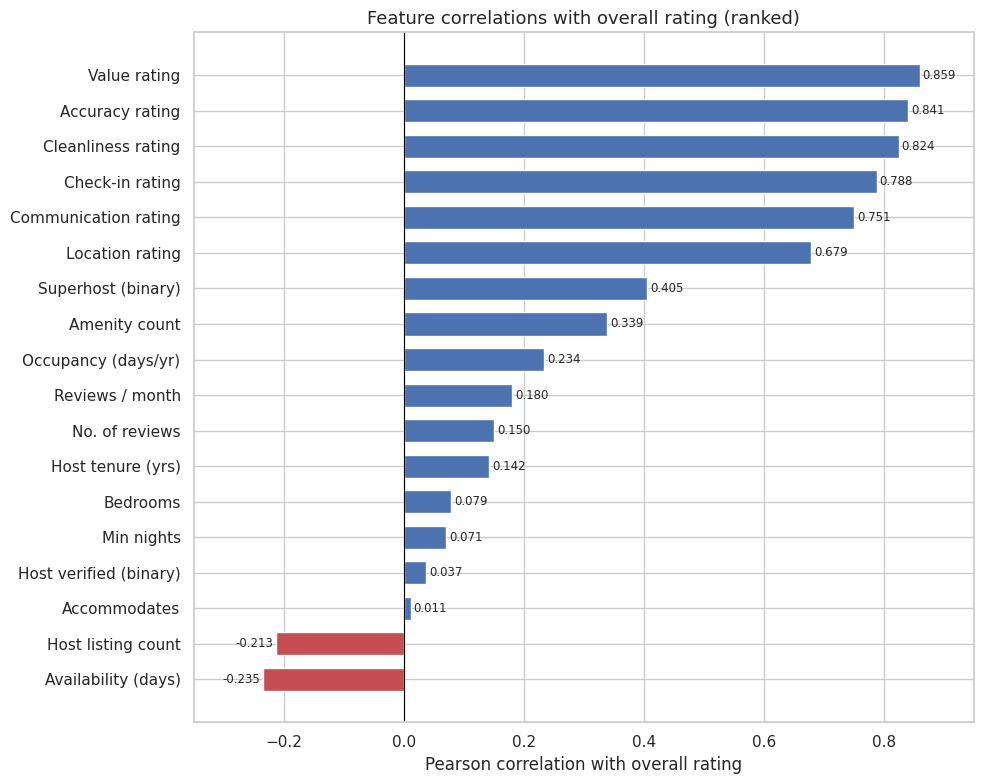


Top 5 positive correlates:
Value rating            0.859281
Accuracy rating         0.840613
Cleanliness rating      0.824496
Check-in rating         0.787734
Communication rating    0.750673

Top 5 negative correlates:
Availability (days)      -0.235298
Host listing count       -0.212562
Accommodates              0.011362
Host verified (binary)    0.036603
Min nights                0.070508


In [15]:
numeric_features = {
    'amenity_count':                  'Amenity count',
    'review_scores_value':            'Value rating',
    'review_scores_accuracy':         'Accuracy rating',
    'review_scores_cleanliness':      'Cleanliness rating',
    'review_scores_checkin':          'Check-in rating',
    'review_scores_communication':    'Communication rating',
    'review_scores_location':         'Location rating',
    'reviews_per_month':              'Reviews / month',
    'number_of_reviews':              'No. of reviews',
    'is_superhost':                   'Superhost (binary)',
    'is_verified':                    'Host verified (binary)',
    'host_tenure_yrs':                'Host tenure (yrs)',
    'availability_365':               'Availability (days)',
    'calculated_host_listings_count': 'Host listing count',
    'accommodates':                   'Accommodates',
    'bedrooms':                       'Bedrooms',
    'minimum_nights':                 'Min nights',
    'instant_book':                   'Instant bookable',
    'estimated_occupancy_l365d':      'Occupancy (days/yr)',
}

corrs = {}
for col, label in numeric_features.items():
    if col in rated.columns:
        r = rated[col].corr(rated['review_scores_rating'])
        if not np.isnan(r):
            corrs[label] = r

corr_series = pd.Series(corrs).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in corr_series.values]
bars = ax.barh(corr_series.index, corr_series.values,
               color=colors, edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_series.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y()+bar.get_height()/2, f'{val:.3f}',
            va='center', ha=ha, fontsize=8.5)
ax.set_xlabel('Pearson correlation with overall rating')
ax.set_title('Feature correlations with overall rating (ranked)', fontsize=13)
ax.set_xlim(-0.35, 0.95)
plt.tight_layout()
plt.savefig('eda_07_ranked_correlations.png', bbox_inches='tight')
plt.show()

print("\nTop 5 positive correlates:")
print(corr_series.tail(5).iloc[::-1].to_string())
print("\nTop 5 negative correlates:")
print(corr_series.head(5).to_string())

# Modeling + Interpretation

*  Confusion Matrix, Accuracy, Precision, Recall
*   make classification charts
*   ROC Curve
*   random forest + oods ratio







In [16]:
# Define classification target (1 = high rating, 0 = not)
rated = rated.copy()
rated['high_rating'] = (rated['review_scores_rating'] >= 4.75).astype(int)

Build Modeling Dataset

In [17]:
rated = df.dropna(subset=['review_scores_rating']).copy()

#target variable
rated['high_rating'] = (rated['review_scores_rating'] >= 4.75).astype(int)

features = [ #selection

    'amenity_count',
    'is_superhost',
    'is_verified',
    'instant_book',
    'host_tenure_yrs',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'calculated_host_listings_count',
    'accommodates',
    'bedrooms',
    'minimum_nights'
]

#dataset *FIXED*
model_df = rated[features + ['high_rating']].copy()

#missing values
model_df = model_df.fillna(model_df.median(numeric_only=True))

#Splitting features and target!
X = model_df[features]
y = model_df['high_rating']

#test the split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Quick check
print("Dataset shape:", model_df.shape)
print("Class balance:\n", y.value_counts())

Dataset shape: (395, 13)
Class balance:
 high_rating
1    261
0    134
Name: count, dtype: int64


Train Models

In [18]:
rated = df.dropna(subset=['review_scores_rating']).copy()

#Targets variable
rated['high_rating'] = (rated['review_scores_rating'] >= 4.75).astype(int)

# Features
features = [
    'amenity_count',
    'is_superhost',
    'is_verified',
    'instant_book',
    'host_tenure_yrs',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'calculated_host_listings_count',
    'accommodates',
    'bedrooms',
    'minimum_nights'
]

#Constructing dataset
model_df = rated[features + ['high_rating']].copy()
for col in features:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# *Split*
X = model_df[features]
y = model_df['high_rating']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# checks
print("Dataset size:", model_df.shape)
print("Class balance:\n", y.value_counts())
print("Remaining NaNs:\n", X.isnull().sum())

Dataset size: (395, 13)
Class balance:
 high_rating
1    261
0    134
Name: count, dtype: int64
Remaining NaNs:
 amenity_count                       0
is_superhost                        0
is_verified                         0
instant_book                      395
host_tenure_yrs                     0
number_of_reviews                   0
reviews_per_month                   0
availability_365                    0
calculated_host_listings_count      0
accommodates                        0
bedrooms                            0
minimum_nights                      0
dtype: int64


### Confusion Matrices

In [19]:
# Ensure rated exists
rated = df.dropna(subset=['review_scores_rating']).copy()

# Target
rated['high_rating'] = (rated['review_scores_rating'] >= 4.75).astype(int)

# Features
features = [
    'amenity_count',
    'is_superhost',
    'is_verified',
    'instant_book',
    'host_tenure_yrs',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'calculated_host_listings_count',
    'accommodates',
    'bedrooms',
    'minimum_nights'
]

#Constructing dataset
X = rated[features]
y = rated['high_rating']

#Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#THEN impute!
imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# **FINALIZED check**
print("Any NaNs left in X_train?", np.isnan(X_train).any())
print("Any NaNs left in X_test?", np.isnan(X_test).any())

Any NaNs left in X_train? False
Any NaNs left in X_test? False


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['instant_book']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['instant_book']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [20]:
#print(len(coefficients))
#print(len(features))
#print(X.columns)

### Logistic Regression Odds Ratio

In [21]:
# Remove constant columns
X_clean = X.loc[:, X.nunique() > 1]

# Combine X + y to handle NaNs safely
model_df = X_clean.copy()
model_df['target'] = y

# Drop rows with NaNs
model_df = model_df.dropna()

# Split again
X_final = model_df.drop(columns=['target'])
y_final = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Odds ratios
coefficients = log_model.coef_[0]
odds_ratios = np.exp(coefficients)

odds_df = pd.DataFrame({
    'Feature': X_final.columns,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
}).sort_values(by='Odds Ratio', ascending=False)

print(odds_df)

                           Feature  Coefficient  Odds Ratio
1                     is_superhost     2.468041   11.799314
9                         bedrooms     0.060290    1.062145
10                  minimum_nights     0.034213    1.034805
0                    amenity_count     0.026550    1.026905
5                reviews_per_month     0.010228    1.010280
4                number_of_reviews     0.001516    1.001517
6                 availability_365    -0.001909    0.998093
7   calculated_host_listings_count    -0.044497    0.956479
8                     accommodates    -0.058873    0.942826
3                  host_tenure_yrs    -0.132246    0.876125
2                      is_verified    -0.286837    0.750634


###Random Forest feature importances

In [22]:
#Fit model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
model = rf

#Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [23]:
#Metrics
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf)}")
print(f"Precision: {precision_score(y_test, y_pred_rf)}")
print(f"Recall   : {recall_score(y_test, y_pred_rf)}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf)}")

Accuracy : 0.7215189873417721
Precision: 0.8
Recall   : 0.7692307692307693
ROC-AUC  : 0.801994301994302


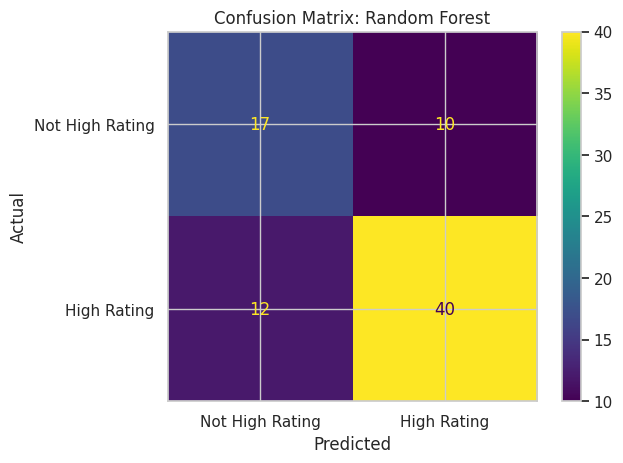

In [24]:
#Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Not High Rating', 'High Rating']).plot()
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
#Redefine Feature Names
feature_names = [
    'amenity_count',
    'is_superhost',
    'is_verified',
    'host_tenure_yrs',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'calculated_host_listings_count',
    'accommodates',
    'bedrooms',
    'minimum_nights'
]

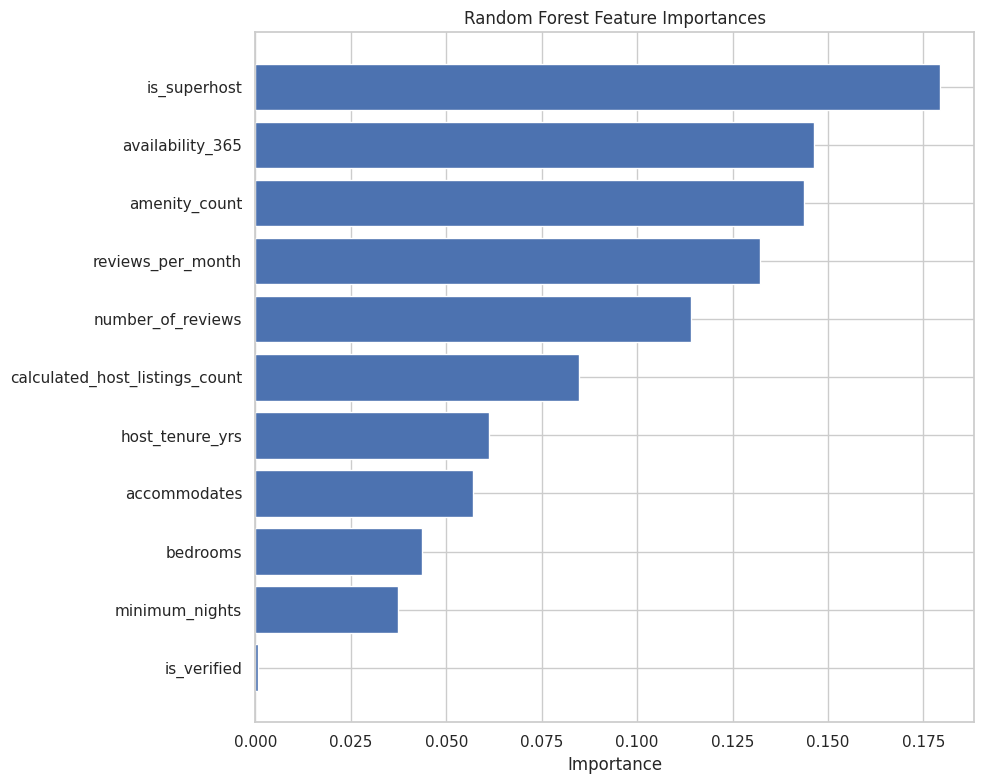

In [26]:
#Feature Importances
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importances.index, importances.values)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### ROC Curves

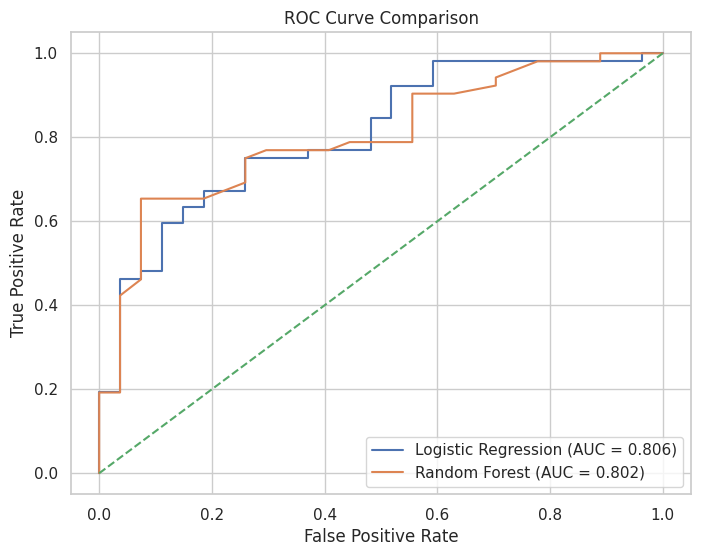

In [27]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Logistic Regression probabilities
log_probs = log_model.predict_proba(X_test)[:, 1]

# Random Forest probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# Compute AUC
auc_log = roc_auc_score(y_test, log_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

#Plot BOTH curves
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

# baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

 Classification charts, predicted probability distributions, calibration plot

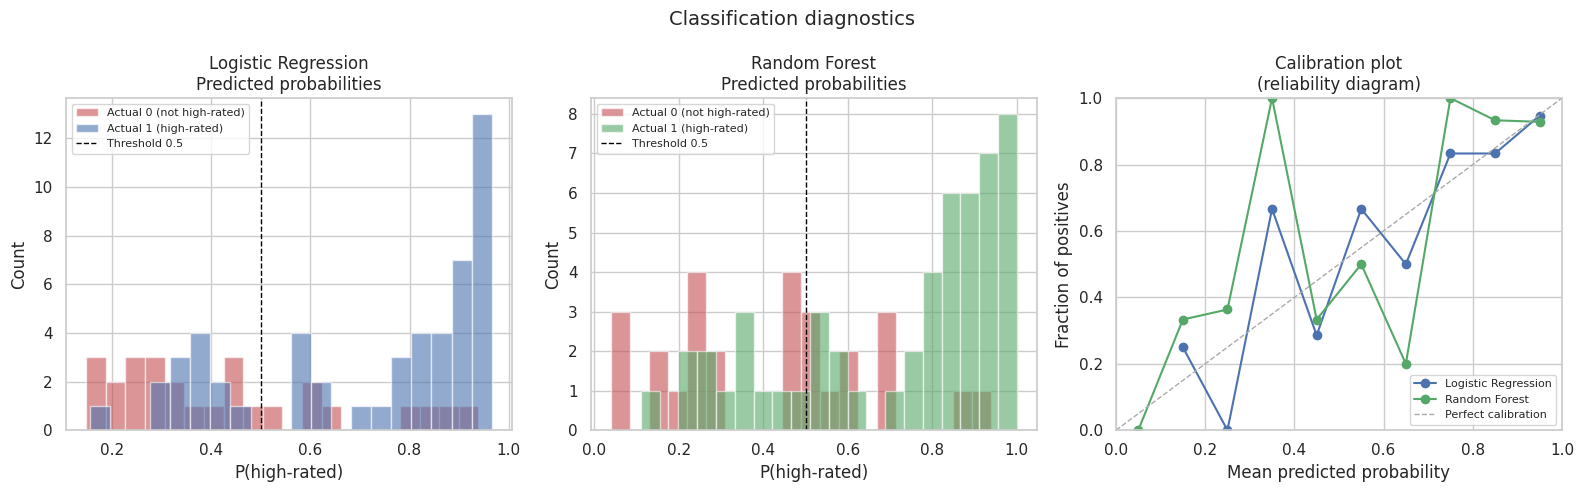

In [28]:
# LR predicted probability distribution
y_test = y_test.reset_index(drop=True)

y_pred_lr = log_model.predict(X_test)
y_prob_lr  = log_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Classification diagnostics', fontsize=14)

axes[0].hist(y_prob_lr[y_test == 0], bins=20, alpha=0.6,
             color='#C44E52', label='Actual 0 (not high-rated)', edgecolor='white')
axes[0].hist(y_prob_lr[y_test == 1], bins=20, alpha=0.6,
             color='#4C72B0', label='Actual 1 (high-rated)', edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
axes[0].set_title('Logistic Regression\nPredicted probabilities')
axes[0].set_xlabel('P(high-rated)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# RF predicted probability
axes[1].hist(y_prob_rf[y_test == 0], bins=20, alpha=0.6,
             color='#C44E52', label='Actual 0 (not high-rated)', edgecolor='white')
axes[1].hist(y_prob_rf[y_test == 1], bins=20, alpha=0.6,
             color='#55A868', label='Actual 1 (high-rated)', edgecolor='white')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
axes[1].set_title('Random Forest\nPredicted probabilities')
axes[1].set_xlabel('P(high-rated)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

# Calibration Plot

for probs, label, color in [
        (y_prob_lr, 'Logistic Regression', '#4C72B0'),
        (y_prob_rf, 'Random Forest',       '#55A868')]:
    bin_edges   = np.linspace(0, 1, 11)
    bin_centers, actual_rates = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() > 0:
            bin_centers.append((lo + hi) / 2)
            actual_rates.append(y_test[mask].mean())
    axes[2].plot(bin_centers, actual_rates, marker='o',
                 linewidth=1.5, color=color, label=label)

axes[2].plot([0, 1], [0, 1], '--', color='#aaa', linewidth=1,
             label='Perfect calibration')
axes[2].set_title('Calibration plot\n(reliability diagram)')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Fraction of positives')
axes[2].legend(fontsize=8)
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('model_classification_charts.png', bbox_inches='tight')
plt.show()

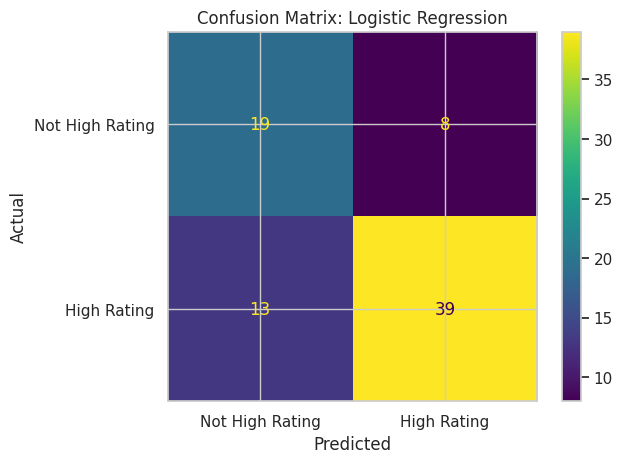

In [29]:
# LR Confusion Matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Not High Rating', 'High Rating']).plot()
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Final Model comparison summary

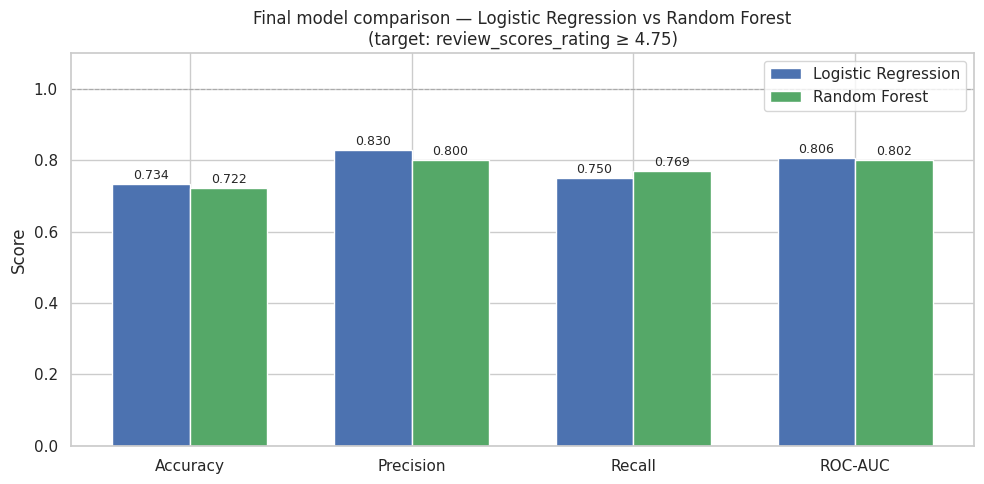


Final Model Performance Summary
           Logistic Regression  Random Forest
Accuracy                 0.734          0.722
Precision                0.830          0.800
Recall                   0.750          0.769
ROC-AUC                  0.806          0.802


In [30]:
metrics = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
lr_scores = [
    accuracy_score(y_test,  y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test,    y_pred_lr),
    roc_auc_score(y_test,   y_prob_lr),
]
rf_scores = [
    accuracy_score(y_test,  y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test,    y_pred_rf),
    roc_auc_score(y_test,   y_prob_rf),
]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, lr_scores, width,
               label='Logistic Regression', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, rf_scores, width,
               label='Random Forest',       color='#55A868', edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Final model comparison — Logistic Regression vs Random Forest\n'
             '(target: review_scores_rating ≥ 4.75)')
ax.axhline(1.0, color='#aaa', linestyle='--', linewidth=0.8)
ax.legend()

plt.tight_layout()
plt.savefig('model_final_comparison.png', bbox_inches='tight')
plt.show()

# Print summary table
summary = pd.DataFrame({
    'Logistic Regression': lr_scores,
    'Random Forest':       rf_scores,
}, index=metrics).round(3)
print("\nFinal Model Performance Summary")
print(summary.to_string())